# マルチモーダルLLMによる画像理解の比較  
### Qwen3-VL-4B-Instruct vs OpenAI multimodal model

## 目的

ローカル環境で動作する **Qwen3-VL-4B-Instruct** と、クラウドAPIで利用する **OpenAIのマルチモーダルモデル** に同一の画像・同一のプロンプトを与え、画像理解の違いを比較する。

本検証ではモデルごとの追加チューニングやプロンプト最適化を行わず、認識できた内容だけでなく、部分一致・見落とし・誤認も比較対象とする。

評価画像は次の2種類に分ける。

- `001.png` ～ `005.png`：Ground Truthを事前に固定し、定量評価に使用
- `000.png`：Stable Diffusionで生成した画像。Ground Truthを置かず、定性比較に使用

> **再実行方針**  
> 画像推論とJudge LLMによる評価はすでに実行済みであり、採用した結果をJSONとして固定している。  
> このNotebookの `Run All` ではQwenの再推論・OpenAI API・Judge APIを呼び出さず、保存済みJSONから評価結果を再構成する。

## 1. 検証設計

比較条件を可能な限り揃えるため、以下を共通条件とした。

- 2モデルに同じ評価画像を入力する
- 2モデルに同じ5項目のプロンプトを与える
- Ground Truthは画像理解モデルへ渡さない
- 各画像を独立して分析する
- モデルごとのプロンプト調整は行わない
- 採用した生成結果はJSONへ保存し、評価途中で再生成しない

定量評価では、Ground Truthとモデル回答の意味的な対応を **LLM-as-a-Judge** で整理した後、人間レビューを行い、Ground Truthを47個の **Atomic Fact（最小評価単位）** に分解して最終ラベルを固定する。

評価の流れは次の通り。

```text
評価画像
  ↓
Qwen3-VL / OpenAIによる画像理解
  ↓
固定済みモデル出力JSON
  ↓
Judge LLMによる意味評価
  ↓
Judge生結果JSON
  ↓
人間レビュー
  ↓
Atomic Fact単位へ正規化
  ↓
Precision / Recall / F1-score
```

In [1]:
from pathlib import Path
from PIL import Image
from IPython.display import display, Markdown
from importlib.metadata import version, PackageNotFoundError
from collections import Counter
import json
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch


# ============================================================
# プロジェクトパス
# ============================================================

candidate_dirs = [
    Path.cwd(),
    Path(r"C:\python\multimodal_model_compare"),
]

BASE_DIR = next(
    (
        path
        for path in candidate_dirs
        if (path / "ground_truth.json").exists()
    ),
    Path(r"C:\python\multimodal_model_compare")
)

IMAGE_DIR = BASE_DIR / "images"
RESULT_DIR = BASE_DIR / "results"

GROUND_TRUTH_PATH = BASE_DIR / "ground_truth.json"
QWEN_RESULT_PATH = RESULT_DIR / "qwen_results.json"
OPENAI_RESULT_PATH = RESULT_DIR / "openai_results.json"
JUDGE_RESULT_V2_PATH = RESULT_DIR / "judge_results_v2.json"
JUDGE_REVIEWED_PATH = RESULT_DIR / "judge_results_reviewed.json"
FINAL_EVALUATION_PATH = RESULT_DIR / "final_evaluation.json"
QUALITATIVE_RESULT_PATH = RESULT_DIR / "qualitative_000_results.json"


required_paths = [
    GROUND_TRUTH_PATH,
    QWEN_RESULT_PATH,
    OPENAI_RESULT_PATH,
    JUDGE_RESULT_V2_PATH,
    JUDGE_REVIEWED_PATH,
    FINAL_EVALUATION_PATH,
    QUALITATIVE_RESULT_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "必要なファイルが見つかりません:\n"
        + "\n".join(str(path) for path in missing_paths)
    )


def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"


print("Project:", BASE_DIR)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", package_version("transformers"))
print("Matplotlib:", package_version("matplotlib"))
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Project: C:\python\multimodal_model_compare
Python: 3.12.14
PyTorch: 2.14.0+cu126
Transformers: 4.57.6
Matplotlib: 3.11.2
CUDA: True
GPU: NVIDIA GeForce RTX 4070


## 2. 評価画像とGround Truth

`001.png` ～ `005.png` では、画像から確認できる内容をモデル出力の確認前にGround Truthとして固定した。Ground Truthは後からモデル回答に合わせて変更しない。

5項目は共通プロンプトの構造と対応している。

1. 主な対象
2. 対象同士の関係・配置
3. 背景・周囲
4. 画像内の文字
5. 画像全体の意味・種類

Ground Truth形式: OK

===== 001.png =====


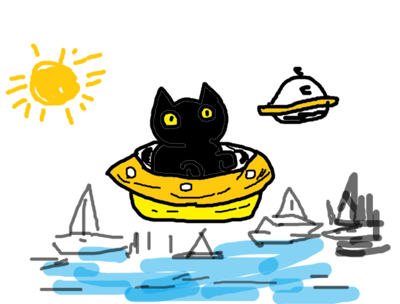

Ground Truth
1. 主な対象：黒猫、UFO、ヨット、太陽が描かれている
2. 対象同士の関係・配置：黒猫が黄色いUFOに乗っており、右上に別のUFOが飛んでいる
3. 背景・周囲：海に複数のヨットが浮かんでいる
4. 画像内の文字：文字なし
5. 画像全体の意味・種類：黒猫とUFOが海辺にいる場面を描いた手書きイラスト

===== 002.png =====


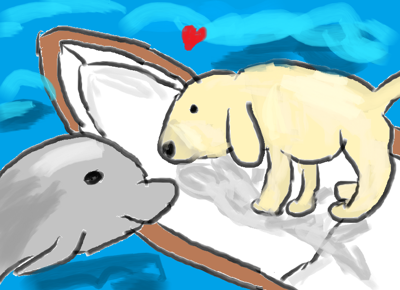

Ground Truth
1. 主な対象：黄色い犬、灰色のイルカ、小さな船、赤いハートが描かれている
2. 対象同士の関係・配置：犬が小さな船の上に立ち、イルカが船の近くにいる
3. 背景・周囲：海上の場面が描かれている
4. 画像内の文字：文字なし
5. 画像全体の意味・種類：犬とイルカが海上で向き合い、上部にハートが描かれた手書きイラスト

===== 003.png =====


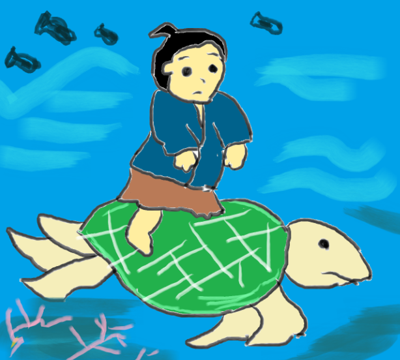

Ground Truth
1. 主な対象：人物、大きなウミガメ、複数の魚が描かれている
2. 対象同士の関係・配置：人物がウミガメの甲羅に乗っている
3. 背景・周囲：水中に複数の魚や海底の植物が描かれている
4. 画像内の文字：文字なし
5. 画像全体の意味・種類：人物がウミガメに乗って水中を進む場面を描いた手書きイラスト

===== 004.png =====


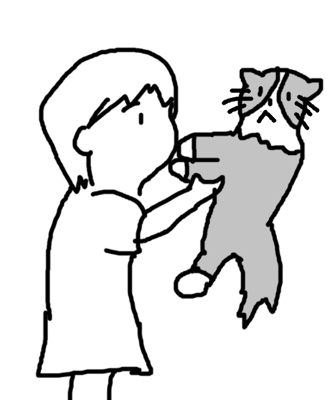

Ground Truth
1. 主な対象：人物と猫が描かれている
2. 対象同士の関係・配置：人物が猫を両手で持ち、前方に持ち上げている
3. 背景・周囲：背景には目立った物体が描かれていない
4. 画像内の文字：文字なし
5. 画像全体の意味・種類：人物が猫を持ち上げている様子を描いた白黒の線画

===== 005.png =====


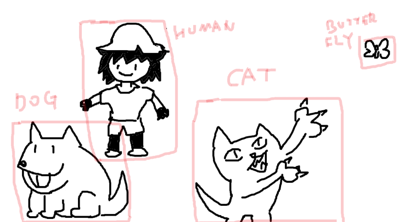

Ground Truth
1. 主な対象：犬、人物、猫、蝶が描かれている
2. 対象同士の関係・配置：犬、人物、猫、蝶がそれぞれ矩形で囲まれている
3. 背景・周囲：白い背景に4つの対象が配置されている
4. 画像内の文字：DOG、HUMAN、CAT、BUTTERFLYと表示されている
5. 画像全体の意味・種類：物体検知結果を模した図になっている



In [2]:
with open(GROUND_TRUTH_PATH, "r", encoding="utf-8") as f:
    ground_truth = json.load(f)

expected_prefixes = [
    "1. 主な対象：",
    "2. 対象同士の関係・配置：",
    "3. 背景・周囲：",
    "4. 画像内の文字：",
    "5. 画像全体の意味・種類：",
]

for image_name, items in ground_truth.items():
    if len(items) != 5:
        raise ValueError(
            f"{image_name}: Ground Truthは5項目である必要があります。"
        )

    for item, prefix in zip(items, expected_prefixes):
        if not item.startswith(prefix):
            raise ValueError(
                f"{image_name}: Ground Truth形式が不正です。\n"
                f"期待: {prefix}\n実際: {item}"
            )

print("Ground Truth形式: OK\n")

for image_name, items in ground_truth.items():
    print(f"===== {image_name} =====")

    with Image.open(IMAGE_DIR / image_name) as img:
        image = img.convert("RGB")
        image.thumbnail((400, 400))
        display(image)

    print("Ground Truth")
    for item in items:
        print(item)
    print()

## 3. 共通プロンプト

画像理解モデルにはGround Truthを渡さず、次の共通プロンプトのみを使用した。  
項目ごとの役割を固定することで、モデル間の回答構造を揃えて比較しやすくしている。

In [3]:
analysis_prompt = """
この画像を見て、以下の5項目を必ず1行ずつ日本語で答えてください。

1. 主な対象
2. 対象同士の関係・配置
3. 背景・周囲
4. 画像内の文字
5. 画像全体の意味・種類

条件：
・各項目は1文だけ
・同じ内容を繰り返さない
・1～4は画像から直接確認できる内容を答える
・5は画像全体から合理的に判断できる範囲で答える
・判断できない場合は「判断困難」と答える
・文字がない場合は「文字なし」と答える
・前置きや補足説明は不要
"""

print(analysis_prompt)


この画像を見て、以下の5項目を必ず1行ずつ日本語で答えてください。

1. 主な対象
2. 対象同士の関係・配置
3. 背景・周囲
4. 画像内の文字
5. 画像全体の意味・種類

条件：
・各項目は1文だけ
・同じ内容を繰り返さない
・1～4は画像から直接確認できる内容を答える
・5は画像全体から合理的に判断できる範囲で答える
・判断できない場合は「判断困難」と答える
・文字がない場合は「文字なし」と答える
・前置きや補足説明は不要



## 4. 比較モデルと固定済み出力

| 項目 | Qwen3-VL | OpenAI |
| --- | --- | --- |
| モデル | `Qwen/Qwen3-VL-4B-Instruct` | `gpt-5.6-terra` |
| 実行場所 | ローカルGPU | クラウドAPI |
| 画像入力 | PIL Image | `input_image` |
| 主な設定 | `bfloat16`, `do_sample=False` | `detail="high"`, reasoningなし |
| 出力保存 | `qwen_results.json` | `openai_results.json` |

Qwen3-VLはRTX 4070 12GB環境で実行した。OpenAI側も同一プロンプト・同一画像を使用し、Ground Truthは入力していない。

生成モデルは再実行によって回答表現や認識内容が変化する可能性があるため、本評価では採用した出力をJSONに固定して使用する。処理時間も保存しているが、ローカルGPUとクラウドAPIでは実行条件が異なるため、速度性能の直接比較には用いない。

【001.png】


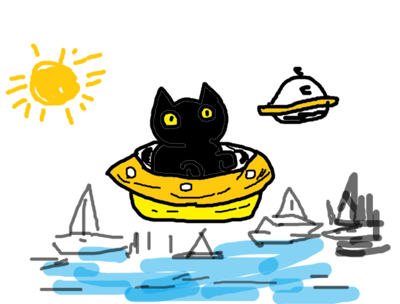

【Qwen3-VL】
1. 黒い猫が黄色い宇宙船に乗っている。
2. 猫は宇宙船の中央に座り、右上には別の宇宙船が浮かんでいる。
3. 背景には太陽と水面上の帆船が描かれている。
4. 文字なし。
5. 猫が宇宙旅行をしている様子を描いたファンタジーイラスト。
処理時間（参考）: 5.02 sec

【OpenAI】
1. 主な対象：黄色いUFOに乗った黒猫が描かれている。  
2. 対象同士の関係・配置：黒猫は画面中央のUFO内に座り、右上には別の小型UFOが浮かんでいる。  
3. 背景・周囲：左上に太陽、下部に青い水面と灰色の山や建物のような線画がある。  
4. 画像内の文字：文字なし。  
5. 画像全体の意味・種類：黒猫とUFOを題材にした子ども向けの手描き風イラストである。
処理時間（参考）: 5.85 sec

【002.png】


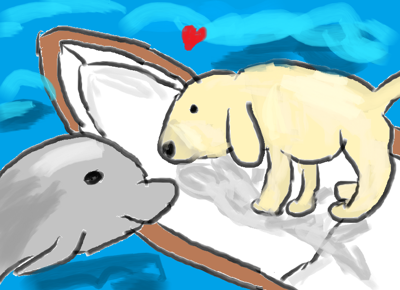

【Qwen3-VL】
1. 主な対象は、灰色のイルカと黄色い犬。
2. 対象同士の関係・配置は、イルカが犬の前で顔を近づけ、犬はイルカを向いて立っている。
3. 背景・周囲は、青い海と空で、空には赤いハートが描かれている。
4. 画像内の文字はなし。
5. 画像全体の意味・種類は、動物たちの愛や親密さを表現したイラスト。
処理時間（参考）: 6.54 sec

【OpenAI】
1. 主な対象：灰色のイルカと淡い黄色の子犬が描かれています。  
2. 対象同士の関係・配置：子犬がイルカの背中付近に乗り、互いに鼻先を近づけています。  
3. 背景・周囲：青い海と空のような背景に、白い波や赤いハートが見えます。  
4. 画像内の文字：文字なし。  
5. 画像全体の意味・種類：動物同士の親しみや愛情を表した手描き風のイラストです。
処理時間（参考）: 4.48 sec

【003.png】


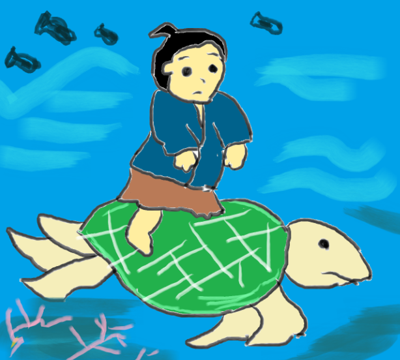

【Qwen3-VL】
1. 主な対象は、青い服を着た人物と緑の甲羅を持つ亀。
2. 人物は亀の背中に乗っており、亀は水を泳いでいる。
3. 背景・周囲は青い水と、空中的に浮かぶ魚が描かれている。
4. 画像内の文字はなし。
5. 画像全体の意味・種類は、水中で亀に乗る人物の冒険的な情景を描いたイラスト。
処理時間（参考）: 6.29 sec

【OpenAI】
1. 主な対象：緑色の甲羅を持つウミガメと、その背中に乗った人物が描かれている。  
2. 対象同士の関係・配置：人物はウミガメの甲羅の中央付近にまたがるように座っている。  
3. 背景・周囲：青い海中を思わせる背景に、水流、魚のような黒い影、下部のサンゴがある。  
4. 画像内の文字：文字なし。  
5. 画像全体の意味・種類：海中でウミガメに乗る人物を表した手描き風のイラストである。
処理時間（参考）: 3.78 sec

【004.png】


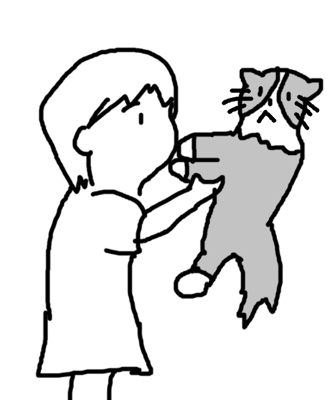

【Qwen3-VL】
1. 主な対象は人間と猫である。
2. 対象同士の関係・配置は、人間が猫を抱き上げている。
3. 背景・周囲は描かれていない。
4. 画像内の文字はなし。
5. 画像全体の意味・種類は、人間が猫を抱き上げる様子を示すイラストである。
処理時間（参考）: 5.06 sec

【OpenAI】
1. 主な対象：人物と灰色の猫が描かれています。  
2. 対象同士の関係・配置：人物が両手で猫を持ち上げて向かい合っています。  
3. 背景・周囲：背景は白地で、ほかの物は描かれていません。  
4. 画像内の文字：文字なし。  
5. 画像全体の意味・種類：猫を抱き上げる人を表した手描き風のイラストです。
処理時間（参考）: 2.31 sec

【005.png】


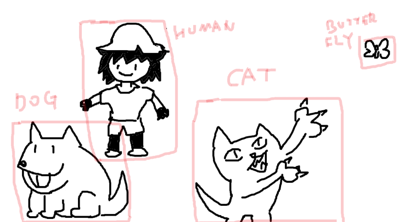

【Qwen3-VL】
1. 主な対象は人間、犬、猫、蝶々の4つのキャラクター。
2. 対象同士の関係・配置は、人間が中央上部、犬が左下、猫が右下、蝶々が右上に配置されている。
3. 背景・周囲は白地で、各キャラクターはピンクの枠で囲まれている。
4. 画像内の文字は「HUMAN」「DOG」「CAT」「BUTTER FLY」および蝶々のイラストに付随する記号。
5. 画像全体の意味・種類は、動物と人間のキャラクターを分類する図解である。
処理時間（参考）: 8.52 sec

【OpenAI】
1. 主な対象は、犬、帽子をかぶった人物、ポーズを取る猫の手描きイラストです。  
2. 犬は左下、人物は中央上、猫は右下の枠内に配置されています。  
3. 白い背景に、各イラストを囲む薄いピンク色の枠線があります。  
4. 画像内には「DOG」「HUMAN」「CAT」「BUTTERFLY」と読める文字があります。  
5. 画像全体は、犬・人間・猫・蝶を題材にした手描きの分類または紹介用スケッチです。
処理時間（参考）: 3.60 sec



In [4]:
def load_model_results(path, expected_images, label):
    with open(path, "r", encoding="utf-8") as f:
        results = json.load(f)

    required_keys = {
        "model",
        "image",
        "response",
        "elapsed_time",
    }

    actual_images = [
        result.get("image")
        for result in results
    ]

    if actual_images != expected_images:
        raise ValueError(
            f"{label}: 画像順がGround Truthと一致しません。\n"
            f"Ground Truth: {expected_images}\n"
            f"Results: {actual_images}"
        )

    for result in results:
        missing = (
            required_keys
            - set(result.keys())
        )
        if missing:
            raise ValueError(
                f"{label} / {result.get('image', 'unknown')}: "
                f"必須項目が不足しています: {missing}"
            )

    return results


expected_images = list(ground_truth.keys())

qwen_results = load_model_results(
    QWEN_RESULT_PATH,
    expected_images,
    "Qwen3-VL"
)

openai_results = load_model_results(
    OPENAI_RESULT_PATH,
    expected_images,
    "OpenAI"
)


for qwen_result, openai_result in zip(
    qwen_results,
    openai_results
):
    image_name = qwen_result["image"]

    print("=" * 80)
    print(f"【{image_name}】")
    print("=" * 80)

    with Image.open(IMAGE_DIR / image_name) as img:
        image = img.convert("RGB")
        image.thumbnail((400, 400))
        display(image)

    print("【Qwen3-VL】")
    print(qwen_result["response"])
    print(
        f"処理時間（参考）: "
        f"{qwen_result['elapsed_time']:.2f} sec"
    )

    print()

    print("【OpenAI】")
    print(openai_result["response"])
    print(
        f"処理時間（参考）: "
        f"{openai_result['elapsed_time']:.2f} sec"
    )

    print()

## 5. JSONによる結果固定とデータ系譜

評価途中の再生成や上書きによって比較条件が変わらないよう、処理段階ごとにJSONを分けて保存している。

| ファイル | 役割 |
| --- | --- |
| `ground_truth.json` | 001～005の基準情報 |
| `qwen_results.json` | Qwen3-VLの固定済み画像分析結果 |
| `openai_results.json` | OpenAIの固定済み画像分析結果 |
| `judge_results_v2.json` | Judge LLMが生成した生の評価結果 |
| `judge_results_reviewed.json` | Judge結果を人間レビューした結果 |
| `final_evaluation.json` | 47 Atomic Facts、最終ラベル、集計値、Strict評価値 |
| `qualitative_000_results.json` | 000.pngのGround Truthなし定性比較結果 |

`judge_results_v2.json` は**生結果として変更しない**。Judgeの分類揺れや重複判定を人間が確認した結果は `judge_results_reviewed.json` に分離し、最終的なAtomic Fact評価は `final_evaluation.json` に保存する。

この構成により、「モデルの元回答」「Judgeの元判定」「人間レビュー後」「最終スコア」の各段階を追跡できる。

In [5]:
with open(JUDGE_RESULT_V2_PATH, "r", encoding="utf-8") as f:
    judge_results_v2 = json.load(f)

with open(JUDGE_REVIEWED_PATH, "r", encoding="utf-8") as f:
    judge_results_reviewed = json.load(f)

with open(FINAL_EVALUATION_PATH, "r", encoding="utf-8") as f:
    final_evaluation = json.load(f)


if len(judge_results_v2.get("qwen", [])) != 5:
    raise ValueError("Judge v2: Qwen結果が5件ではありません。")

if len(judge_results_v2.get("openai", [])) != 5:
    raise ValueError("Judge v2: OpenAI結果が5件ではありません。")

if len(judge_results_reviewed.get("qwen", [])) != 5:
    raise ValueError("Human reviewed: Qwen結果が5件ではありません。")

if len(judge_results_reviewed.get("openai", [])) != 5:
    raise ValueError("Human reviewed: OpenAI結果が5件ではありません。")

atomic_fact_count = sum(
    len(facts)
    for facts in final_evaluation["atomic_facts"].values()
)

if atomic_fact_count != 47:
    raise ValueError(
        f"Atomic Fact数が47ではありません: {atomic_fact_count}"
    )

print(
    "Judge raw / Human reviewed / Final evaluation: OK"
)
print(f"Atomic Facts: {atomic_fact_count}")

Judge raw / Human reviewed / Final evaluation: OK
Atomic Facts: 47


## 6. 評価方法

### LLM-as-a-Judge

単純な文字列一致では、`ヨット` と `帆船`、`ウミガメ` と `亀` のような意味的に近い表現を適切に扱えない。そのため、Ground Truthと候補回答をテキストのみでJudge LLM（`gpt-5.6-sol`）へ渡し、意味的な一致を整理した。

Judgeでは以下を区別する。

- `matched`：Ground Truthと十分に一致
- `partial`：意味は近いが、種類・数量・属性・配置などが不完全
- `missed`：Ground Truthにある事実を認識できていない
- `unsupported`：Ground Truthと明確に矛盾する、または明確な誤認
- `unverified`：Ground Truthにはないが、Judgeだけでは正誤を断定できない追加情報

Ground Truthは画像内の全情報を列挙したものではないため、「Ground Truthに書かれていない」という理由だけで追加情報を誤りにはしない。

### 人間レビューとAtomic Fact

LLM-as-a-Judgeは意味比較に有効だが、`partial` と `missed` の境界や事実の粒度が揺れることがある。そこでJudgeの生結果を人間が確認し、同一事実の二重減点や、モデル間で基準が揃っていない判定を補正した。

Notebookでは評価過程を読みやすくするため、人間レビューの代表例のみを後段に表示する。**全10件の人間レビュー済みJudge結果は `judge_results_reviewed.json` に保存**し、47個のAtomic Factに対する最終ラベルは **`final_evaluation.json` に保存**している。

さらにGround Truthを47個のAtomic Factへ分解し、各モデルについて各事実を必ず次の1つへ固定した。

- `MATCH`
- `PARTIAL`
- `MISS`

追加情報の `unsupported` / `unverified` はAtomic Factとは別に集計する。  
`unverified` は正誤を確定できないため、False Positiveには含めない。

### 人間レビューの代表例

Judge LLMの一次評価だけでは、意味的に近い表現をどこまで一致とみなすか、また見落としと部分一致をどう分けるかに揺れが生じる。そこで、**Ground Truth・固定済みLLM出力・Judge結果を照合し、人間が最終判定を確認した**。

以下では、その判断過程が分かりやすい代表例だけを表示する。表の「一致した点」はモデルがGround Truthの意味を保持できた部分、「差異」は不足・言い換え・誤認した部分を示す。

- Notebook上の表示：代表例のみ
- 全件の人間レビュー済みJudge結果：`judge_results_reviewed.json`
- 47 Atomic Factsの最終 `MATCH / PARTIAL / MISS`：`final_evaluation.json`

この表はスコアを再計算するための別評価ではなく、**最終ラベルがどのような観点で決められたかを説明するための監査用サンプル**である。


In [6]:
# ============================================================
# 人間レビューの代表例
# - 固定済みLLM出力をそのまま参照
# - Ground TruthはAtomic Factから取得
# - 最終判定はfinal_evaluation.jsonと照合
# ============================================================

def get_model_result(results, image_name):
    return next(
        item
        for item in results
        if item["image"] == image_name
    )


def get_numbered_line(response_text, number):
    prefixes = (
        f"{number}.",
        f"{number}．",
    )

    for line in response_text.splitlines():
        line = line.strip()
        if line.startswith(prefixes):
            return line

    # 想定外の形式でもNotebook全体を止めず、回答全体を表示する
    return response_text.strip().replace("\n", " / ")


def get_atomic_fact_text(image_name, fact_id):
    return next(
        fact["fact"]
        for fact in final_evaluation["atomic_facts"][image_name]
        if fact["id"] == fact_id
    )


def escape_markdown_cell(text):
    return (
        str(text)
        .replace("|", "\\|")
        .replace("\n", "<br>")
    )


review_examples = [
    {
        "model_key": "qwen",
        "model_name": "Qwen3-VL",
        "image": "001.png",
        "fact_id": "001_f02",
        "response_item": 1,
        "match": "黄色い飛行物体を認識している",
        "difference": "Ground Truthの「UFO」を「宇宙船」と表現している",
        "expected_label": "PARTIAL",
    },
    {
        "model_key": "qwen",
        "model_name": "Qwen3-VL",
        "image": "002.png",
        "fact_id": "002_f05",
        "response_item": 2,
        "match": "犬とイルカの存在・近い位置関係は捉えている",
        "difference": "犬が小さな船の上に立っている関係を認識していない",
        "expected_label": "MISS",
    },
    {
        "model_key": "qwen",
        "model_name": "Qwen3-VL",
        "image": "005.png",
        "fact_id": "005_f10",
        "response_item": 4,
        "match": "BUTTERFLYに相当する文字列を認識している",
        "difference": "「BUTTERFLY」を「BUTTER FLY」と空白入りで認識している",
        "expected_label": "PARTIAL",
    },
    {
        "model_key": "qwen",
        "model_name": "Qwen3-VL",
        "image": "005.png",
        "fact_id": "005_f11",
        "response_item": 5,
        "match": "対象を識別・分類する図という大意は捉えている",
        "difference": "「物体検知結果を模した図」までは特定していない",
        "expected_label": "PARTIAL",
    },
    {
        "model_key": "openai",
        "model_name": "OpenAI",
        "image": "002.png",
        "fact_id": "002_f05",
        "response_item": 2,
        "match": "犬とイルカの近接関係は捉えている",
        "difference": "Ground Truthでは犬は船上だが、イルカの背中付近にいると誤認している",
        "expected_label": "MISS",
    },
]

result_sets = {
    "qwen": qwen_results,
    "openai": openai_results,
}

rows = [
    "| Model / Image | Ground Truth（Atomic Fact） | 固定済みLLM出力 | 一致した点 | 差異 | 最終判定 |",
    "| --- | --- | --- | --- | --- | --- |",
]

for example in review_examples:
    model_key = example["model_key"]
    image_name = example["image"]
    fact_id = example["fact_id"]

    actual_label = final_evaluation[
        model_key
    ]["atomic_labels"][image_name][fact_id]

    if actual_label != example["expected_label"]:
        raise ValueError(
            f"{model_key} / {image_name} / {fact_id}: "
            f"想定ラベル {example['expected_label']} と "
            f"保存済みラベル {actual_label} が一致しません。"
        )

    result = get_model_result(
        result_sets[model_key],
        image_name,
    )

    output_excerpt = get_numbered_line(
        result["response"],
        example["response_item"],
    )

    fact_text = get_atomic_fact_text(
        image_name,
        fact_id,
    )

    rows.append(
        "| "
        + escape_markdown_cell(
            f"{example['model_name']} / {image_name}"
        )
        + " | "
        + escape_markdown_cell(fact_text)
        + " | "
        + escape_markdown_cell(output_excerpt)
        + " | "
        + escape_markdown_cell(example["match"])
        + " | "
        + escape_markdown_cell(example["difference"])
        + " | "
        + actual_label
        + " |"
    )


display(
    Markdown(
        "\n".join(rows)
    )
)


| Model / Image | Ground Truth（Atomic Fact） | 固定済みLLM出力 | 一致した点 | 差異 | 最終判定 |
| --- | --- | --- | --- | --- | --- |
| Qwen3-VL / 001.png | 黄色いUFOが描かれている | 1. 黒い猫が黄色い宇宙船に乗っている。 | 黄色い飛行物体を認識している | Ground Truthの「UFO」を「宇宙船」と表現している | PARTIAL |
| Qwen3-VL / 002.png | 犬が小さな船の上に立っている | 2. 対象同士の関係・配置は、イルカが犬の前で顔を近づけ、犬はイルカを向いて立っている。 | 犬とイルカの存在・近い位置関係は捉えている | 犬が小さな船の上に立っている関係を認識していない | MISS |
| Qwen3-VL / 005.png | BUTTERFLYと表示されている | 4. 画像内の文字は「HUMAN」「DOG」「CAT」「BUTTER FLY」および蝶々のイラストに付随する記号。 | BUTTERFLYに相当する文字列を認識している | 「BUTTERFLY」を「BUTTER FLY」と空白入りで認識している | PARTIAL |
| Qwen3-VL / 005.png | 物体検知結果を模した図である | 5. 画像全体の意味・種類は、動物と人間のキャラクターを分類する図解である。 | 対象を識別・分類する図という大意は捉えている | 「物体検知結果を模した図」までは特定していない | PARTIAL |
| OpenAI / 002.png | 犬が小さな船の上に立っている | 2. 対象同士の関係・配置：子犬がイルカの背中付近に乗り、互いに鼻先を近づけています。 | 犬とイルカの近接関係は捉えている | Ground Truthでは犬は船上だが、イルカの背中付近にいると誤認している | MISS |

In [7]:
atomic_facts = final_evaluation["atomic_facts"]

qwen_atomic_labels = (
    final_evaluation["qwen"]["atomic_labels"]
)

openai_atomic_labels = (
    final_evaluation["openai"]["atomic_labels"]
)

valid_labels = {
    "MATCH",
    "PARTIAL",
    "MISS",
}


def validate_atomic_labels(
    model_name,
    labels,
    facts_by_image
):
    for image_name, facts in facts_by_image.items():
        expected_ids = {
            fact["id"]
            for fact in facts
        }

        actual_ids = set(
            labels.get(image_name, {}).keys()
        )

        if expected_ids != actual_ids:
            raise ValueError(
                f"{model_name} / {image_name}: "
                "Atomic Fact IDが一致しません。"
            )

        invalid = {
            fact_id: label
            for fact_id, label
            in labels[image_name].items()
            if label not in valid_labels
        }

        if invalid:
            raise ValueError(
                f"{model_name} / {image_name}: "
                f"不正なラベルがあります: {invalid}"
            )


validate_atomic_labels(
    "Qwen3-VL",
    qwen_atomic_labels,
    atomic_facts
)

validate_atomic_labels(
    "OpenAI",
    openai_atomic_labels,
    atomic_facts
)


rows = [
    "| Image | Facts | Qwen MATCH | Qwen PARTIAL | Qwen MISS | "
    "OpenAI MATCH | OpenAI PARTIAL | OpenAI MISS |",
    "| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |",
]

for image_name, facts in atomic_facts.items():
    q_counts = Counter(
        qwen_atomic_labels[image_name].values()
    )
    o_counts = Counter(
        openai_atomic_labels[image_name].values()
    )

    rows.append(
        f"| {image_name} | {len(facts)} | "
        f"{q_counts['MATCH']} | {q_counts['PARTIAL']} | {q_counts['MISS']} | "
        f"{o_counts['MATCH']} | {o_counts['PARTIAL']} | {o_counts['MISS']} |"
    )

display(
    Markdown(
        "\n".join(rows)
    )
)

| Image | Facts | Qwen MATCH | Qwen PARTIAL | Qwen MISS | OpenAI MATCH | OpenAI PARTIAL | OpenAI MISS |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 001.png | 9 | 3 | 5 | 1 | 8 | 0 | 1 |
| 002.png | 11 | 6 | 1 | 4 | 7 | 0 | 4 |
| 003.png | 9 | 5 | 2 | 2 | 5 | 3 | 1 |
| 004.png | 7 | 4 | 2 | 1 | 5 | 2 | 0 |
| 005.png | 11 | 9 | 2 | 0 | 10 | 1 | 0 |

## 7. Precision / Recall / F1-score

本検証では、**F1-scoreそのものは標準式**を用い、Atomic FactのラベルをTP / FP / FNへ変換する部分だけを本検証用の **Strict評価** として定義する。

### 指標の意味

**Precision（適合率）** は、モデルが正しい内容として出した情報のうち、どれだけが正しかったかを表す。

$$
Precision = \frac{TP}{TP + FP}
$$

**Recall（再現率）** は、Ground Truthにある事実のうち、どれだけを取りこぼさず認識できたかを表す。

$$
Recall = \frac{TP}{TP + FN}
$$

**F1-score** はPrecisionとRecallの調和平均であり、誤認の少なさと見落としの少なさを1つの値でバランス評価する。

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

同値な式として、

$$
F1 = \frac{2TP}{2TP + FP + FN}
$$

とも書ける。

### 本検証のStrict評価

| 判定 | TP / FP / FNへの変換 |
| --- | --- |
| `MATCH` | TP |
| `PARTIAL` | FP + FN |
| `MISS` | FN |
| `unsupported` | FP |
| `unverified` | 集計対象外 |

`PARTIAL` は意味的に近い回答だが完全一致ではないため、Strict評価では「正解事実を完全には再現できなかった」側をFN、「不完全な表現を出力した」側をFPとして同時に計上する。これは本検証独自の厳格な変換ルールであり、PARTIALを0.5点として扱う一般化された指標ではない。

たとえばQwen3-VLは `MATCH=27 / PARTIAL=12 / MISS=8 / unsupported=2` なので、

- TP = 27
- FP = 12 + 2 = 14
- FN = 12 + 8 = 20

となる。

$$
F1 = \frac{2 \times 27}{2 \times 27 + 14 + 20}
    = \frac{54}{88}
    \approx 0.614
$$

Strict F1だけではPARTIALの多さが見えにくいため、`MATCH / PARTIAL / MISS` の割合も併記する。

In [8]:
def count_atomic_labels(labels):
    counter = Counter()

    for image_labels in labels.values():
        counter.update(
            image_labels.values()
        )

    return counter


def calculate_strict_metrics(
    label_counts,
    additional_counts
):
    tp = label_counts["MATCH"]
    fp = (
        label_counts["PARTIAL"]
        + additional_counts["unsupported"]
    )
    fn = (
        label_counts["PARTIAL"]
        + label_counts["MISS"]
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


def calculate_label_rates(label_counts):
    total = sum(label_counts.values())

    return {
        label: label_counts[label] / total
        for label in [
            "MATCH",
            "PARTIAL",
            "MISS",
        ]
    }


qwen_label_counts = count_atomic_labels(
    qwen_atomic_labels
)

openai_label_counts = count_atomic_labels(
    openai_atomic_labels
)

qwen_additional_counts = (
    final_evaluation["qwen"]["additional_counts"]
)

openai_additional_counts = (
    final_evaluation["openai"]["additional_counts"]
)

qwen_metrics = calculate_strict_metrics(
    qwen_label_counts,
    qwen_additional_counts
)

openai_metrics = calculate_strict_metrics(
    openai_label_counts,
    openai_additional_counts
)

qwen_rates = calculate_label_rates(
    qwen_label_counts
)

openai_rates = calculate_label_rates(
    openai_label_counts
)


# 保存済みの最終値と再計算値が一致することを確認
for model_key, metrics in [
    ("qwen", qwen_metrics),
    ("openai", openai_metrics),
]:
    stored = (
        final_evaluation[model_key]["strict_metrics"]
    )

    for key in [
        "TP",
        "FP",
        "FN",
        "Precision",
        "Recall",
        "F1",
    ]:
        if not np.isclose(
            metrics[key],
            stored[key],
        ):
            raise ValueError(
                f"{model_key}: {key} が保存値と一致しません。"
            )


rows = [
    "| Model | MATCH | PARTIAL | MISS | unsupported | unverified | "
    "Precision | Recall | F1-score |",
    "| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |",
]

for model_name, counts, rates, additional, metrics in [
    (
        "Qwen3-VL",
        qwen_label_counts,
        qwen_rates,
        qwen_additional_counts,
        qwen_metrics,
    ),
    (
        "OpenAI",
        openai_label_counts,
        openai_rates,
        openai_additional_counts,
        openai_metrics,
    ),
]:
    rows.append(
        f"| {model_name} | "
        f"{counts['MATCH']} ({rates['MATCH']:.1%}) | "
        f"{counts['PARTIAL']} ({rates['PARTIAL']:.1%}) | "
        f"{counts['MISS']} ({rates['MISS']:.1%}) | "
        f"{additional['unsupported']} | "
        f"{additional['unverified']} | "
        f"{metrics['Precision']:.3f} | "
        f"{metrics['Recall']:.3f} | "
        f"{metrics['F1']:.3f} |"
    )

display(
    Markdown(
        "\n".join(rows)
    )
)

| Model | MATCH | PARTIAL | MISS | unsupported | unverified | Precision | Recall | F1-score |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Qwen3-VL | 27 (57.4%) | 12 (25.5%) | 8 (17.0%) | 2 | 14 | 0.659 | 0.574 | 0.614 |
| OpenAI | 35 (74.5%) | 6 (12.8%) | 6 (12.8%) | 1 | 23 | 0.833 | 0.745 | 0.787 |

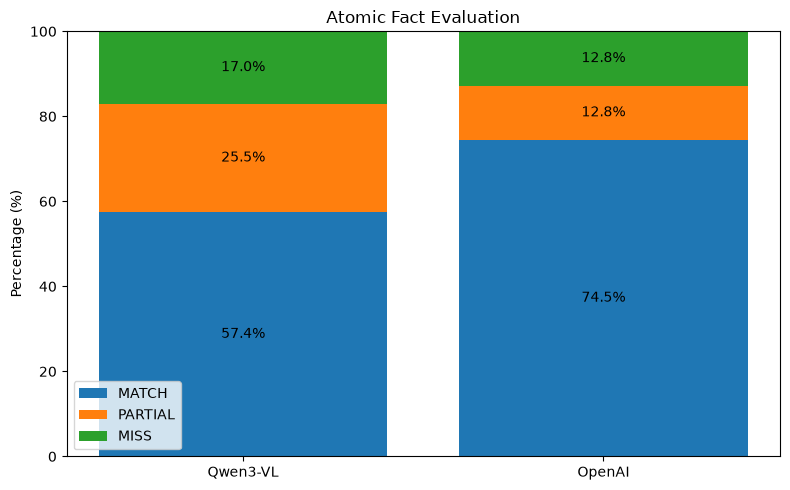

In [9]:
models = [
    "Qwen3-VL",
    "OpenAI",
]

match_rates = [
    qwen_rates["MATCH"] * 100,
    openai_rates["MATCH"] * 100,
]

partial_rates = [
    qwen_rates["PARTIAL"] * 100,
    openai_rates["PARTIAL"] * 100,
]

miss_rates = [
    qwen_rates["MISS"] * 100,
    openai_rates["MISS"] * 100,
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    models,
    match_rates,
    label="MATCH",
)

ax.bar(
    models,
    partial_rates,
    bottom=match_rates,
    label="PARTIAL",
)

bottom_miss = [
    match_rates[i] + partial_rates[i]
    for i in range(len(models))
]

ax.bar(
    models,
    miss_rates,
    bottom=bottom_miss,
    label="MISS",
)

for i in range(len(models)):
    ax.text(
        i,
        match_rates[i] / 2,
        f"{match_rates[i]:.1f}%",
        ha="center",
        va="center",
    )

    ax.text(
        i,
        match_rates[i] + partial_rates[i] / 2,
        f"{partial_rates[i]:.1f}%",
        ha="center",
        va="center",
    )

    ax.text(
        i,
        bottom_miss[i] + miss_rates[i] / 2,
        f"{miss_rates[i]:.1f}%",
        ha="center",
        va="center",
    )

ax.set_ylabel("Percentage (%)")
ax.set_title("Atomic Fact Evaluation")
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

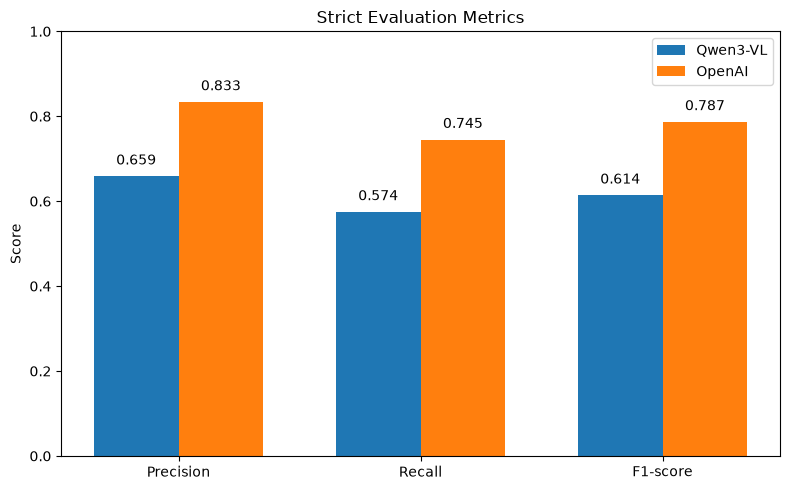

In [10]:
metrics_names = [
    "Precision",
    "Recall",
    "F1-score",
]

qwen_values = [
    qwen_metrics["Precision"],
    qwen_metrics["Recall"],
    qwen_metrics["F1"],
]

openai_values = [
    openai_metrics["Precision"],
    openai_metrics["Recall"],
    openai_metrics["F1"],
]

x = np.arange(
    len(metrics_names)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars_qwen = ax.bar(
    x - width / 2,
    qwen_values,
    width,
    label="Qwen3-VL",
)

bars_openai = ax.bar(
    x + width / 2,
    openai_values,
    width,
    label="OpenAI",
)

ax.set_ylabel("Score")
ax.set_title("Strict Evaluation Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.0)
ax.legend()

for bars in [
    bars_qwen,
    bars_openai,
]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
        )

plt.tight_layout()
plt.show()

## 8. Ground Truthなしの定性比較

`000.png` はStable Diffusionで生成した通常のイラストであり、Ground Truthを設定しない。定量評価と同じ共通プロンプトを使い、Qwen3-VLとOpenAIが画像全体をどのように解釈するかを比較する。

この結果はPrecision / Recall / F1-scoreには含めず、対象認識、配置、背景、画像全体の意味付けなどの違いを人間が確認するための参考結果として扱う。

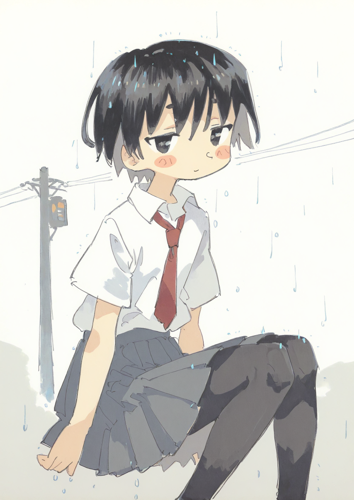

【Qwen3-VL】
1. 主な対象は雨の中で座っている黒髪の少女。
2. 少女は画面中央に位置し、右側に電柱が配置されている。
3. 背景には雨が降っている空と電柱があり、周囲は薄い色調で描かれている。
4. 画像内の文字はなし。
5. 画像全体の意味・種類は、雨の中の学校制服を着た少女の静かな瞬間を描いたイラスト。

【OpenAI】
1. 主な対象：雨に濡れた黒髪の制服姿の少女が描かれている。  
2. 対象同士の関係・配置：少女は画面中央から右側に座り、左後方に電柱が配置されている。  
3. 背景・周囲：白い空間に雨粒、電線、電柱が見える。  
4. 画像内の文字：文字なし。  
5. 画像全体の意味・種類：雨の日に屋外で座る学生を描いたアニメ風イラストである。


In [11]:
with open(
    QUALITATIVE_RESULT_PATH,
    "r",
    encoding="utf-8",
) as f:
    qualitative_results = json.load(f)

if qualitative_results.get("image") != "000.png":
    raise ValueError(
        "定性比較結果の画像が000.pngではありません。"
    )

if qualitative_results.get("ground_truth") is not None:
    raise ValueError(
        "000.pngにはGround Truthを設定しません。"
    )


image_000 = Image.open(
    IMAGE_DIR / "000.png"
)

display_image = image_000.copy()
display_image.thumbnail(
    (500, 500)
)

display(display_image)
image_000.close()

print("【Qwen3-VL】")
print(
    qualitative_results[
        "results"
    ]["qwen"]["response"]
)

print()

print("【OpenAI】")
print(
    qualitative_results[
        "results"
    ]["openai"]["response"]
)

## 9. 評価結果の考察

### 定量評価

47個のAtomic Factを用いたStrict評価では、OpenAIがQwen3-VLを上回った。

| Model | MATCH | PARTIAL | MISS | Precision | Recall | F1-score |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Qwen3-VL | 57.4% | 25.5% | 17.0% | 0.659 | 0.574 | 0.614 |
| OpenAI | 74.5% | 12.8% | 12.8% | 0.833 | 0.745 | 0.787 |

OpenAIはMATCH率が高く、Strict評価のPrecision・Recall・F1-scoreもすべて高かった。

一方、Qwen3-VLはMISS 17.0%に対してPARTIALが25.5%と多い。完全に認識できないケースだけでなく、対象や場面の大意は捉えているものの、数量・種類・属性・配置などの細部が不足するケースが比較的多かった。

実例として、UFOを「宇宙船」、ウミガメを一般的な「亀」と表現するなど、意味的には近いがGround Truthと完全一致しない回答が見られた。Strict F1ではPARTIALを厳しく評価しているため、F1-scoreだけでなくPARTIAL率も併記することで認識傾向を補足している。

### `000.png` の定性比較

両モデルとも、黒髪の少女、制服、雨、電柱、文字がないことなど、主要な要素は概ね共通して認識した。

Qwen3-VLは「雨の中の学校制服を着た少女の静かな瞬間」と表現し、画像の雰囲気や情緒まで含めて解釈した。OpenAIは「雨の日に屋外で座る学生を描いたアニメ風イラスト」と表現し、場面と画像種類を比較的明確に分類した。

電柱の位置はQwen3-VLが「右側」、OpenAIが「左後方」と回答しており、同一画像でも構図・位置関係の解釈に差が生じた。定量評価と定性評価を併用することで、単一スコアだけでは見えない説明傾向も確認できた。

## 10. 本検証の制約

- 定量評価画像は5枚、Atomic Factは47件であり、大規模ベンチマークではない。今回のF1-scoreは本評価セットに対する記述的な比較値であり、モデル一般の性能値ではない。
- Ground Truthは事前固定しているが、画像内の全事実を網羅するものではない。このため追加情報を `unsupported` と `unverified` に分け、未記載という理由だけで誤りにしない設計とした。
- Judge LLMにはOpenAI系モデルを使用しているため、OpenAI側の候補回答に有利または不利な評価バイアスが生じる可能性を完全には除去できない。生のJudge結果を人間レビューし、Atomic Fact単位へ正規化することで影響を抑えた。
- `PARTIAL → FP + FN` は本検証独自のStrict変換である。F1-scoreの数式自体は標準式だが、TP / FP / FNへの割り当ては評価設計に依存する。
- Qwen3-VLはローカルGPU、OpenAIはクラウドAPIで実行しているため、保存した処理時間は参考値であり、速度性能の直接比較には使用しない。

## 11. まとめ

同一画像・同一プロンプトという条件で、ローカルのQwen3-VLとクラウド型OpenAIモデルの画像理解を比較した。

定量評価では、Ground Truthを47個のAtomic Factへ分解し、Judge LLMの意味評価を人間レビューした上で `MATCH / PARTIAL / MISS` を固定した。Notebookには一致点・差異が分かる代表例のみを示し、全件の人間レビュー済みJudge結果は `judge_results_reviewed.json`、Atomic Factの最終ラベルは `final_evaluation.json` に保持している。さらにGround Truth外の追加情報を `unsupported / unverified` に分けることで、単なる情報量の多さを不必要に減点しない評価系とした。

本評価セットではOpenAIがStrict F1-score `0.787`、Qwen3-VLが `0.614` となり、OpenAIの完全一致率が高かった。一方でQwen3-VLはPARTIALの割合が比較的高く、「大意は捉えるが細部が不足する」ケースが多いことも確認できた。

また、Stable Diffusion生成画像を用いたGround Truthなしの比較では、主要対象の認識は共通していても、雰囲気・画像種類・位置関係の説明に違いが見られた。

この検証では、モデル比較を単一のスコアだけで終わらせず、**固定済み生成結果、LLM-as-a-Judge、人間レビュー、Atomic Fact、定量指標、定性比較**を組み合わせることで、評価過程を追跡可能な形で整理した。